# CA1: Dataframe Manipulation with Spotify Data

## Introduction
Pandas is an extremely powerful tool to handle large amounts of tabular data. In this compulsory assignment, you will use Pandas to explore one of the TA's personal spotify data in depth. \
\
Additional information:
- Feel free to create additional code cells if you feel that one cell per subtask is not sufficient.
- Remember, Pandas uses very efficient code to handle large amounts of data. For-loops are not efficient. If you ever have to use a for-loop to loop over the rows in the DataFrame, you have *probably* done something wrong.
- Label all graphs and charts if applicable.

## Task
I typically enjoy indie and rock music. I am a big fan of everything from old-fashioned rock and roll like Led Zeppelin and Jimi Hendrix, to newer indie artists like Joji and Lana Del Rey. This is why my spotify wrapped for 2023 came as quite a surprise:

<img src="spotifywrapped.PNG" alt="Image Description" width="20%">


Now, I'm no hater of pop music, but this was unexpected. 
For this assignment, you will investigate my listening habits, including a deep dive into my Ariana Grande listening habits, and try to find an answer to why she was my top artist; was there a fault in the spotify algorithm? Am I actually secretly an *Arianator*? (yes, I did have to look that up). Or am I just lying to myself about how often I listen to guilty pleasure music?

## Part 1: Initial loading and exploration

#### 1.0 Import necessary libraries: 
pandas, numpy, matplotlib.pyplot (other libraries such as seaborn or plotly are also allowed if you want prettier plots). It might also be a good idea to use **os** for task 2.0

In [2]:
import matplotlib.pyplot as plt
# ---- Insert other imports ----
import pandas as pd

#### 1.1 Loading the data
Load the dataset in the file `streaming_history_0.csv` into a Pandas DataFrame called `df_spotify_0`.

In [3]:
df_spotify_0 = pd.read_csv("spotify_data\streaminghistory0.csv")


#### 1.2 Help function
Use the Python command `help` to help you understand how to use the `pd.DataFrame.head` and `pd.DataFrame.tail` methods.

In [4]:
help(pd.DataFrame.head)


Help on function head in module pandas.core.generic:

head(self, n: 'int' = 5) -> 'Self'
    Return the first `n` rows.
    
    This function returns the first `n` rows for the object based
    on position. It is useful for quickly testing if your object
    has the right type of data in it.
    
    For negative values of `n`, this function returns all rows except
    the last `|n|` rows, equivalent to ``df[:n]``.
    
    If n is larger than the number of rows, this function returns all rows.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    same type as caller
        The first `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.tail: Returns the last `n` rows.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >>> df
          animal
    0  alligator

In [5]:
help(pd.DataFrame.tail)

Help on function tail in module pandas.core.generic:

tail(self, n: 'int' = 5) -> 'Self'
    Return the last `n` rows.
    
    This function returns last `n` rows from the object based on
    position. It is useful for quickly verifying data, for example,
    after sorting or appending rows.
    
    For negative values of `n`, this function returns all rows except
    the first `|n|` rows, equivalent to ``df[|n|:]``.
    
    If n is larger than the number of rows, this function returns all rows.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    type of caller
        The last `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.head : The first `n` rows of the caller object.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >>> df
          animal
    

#### 1.3 Getting an overview
Print the first `five` and last `ten` rows of the dataframe. Have a quick look at which columns are in the dataset. 

In [6]:
df_spotify_0.head(5)

,endTime,artistName,trackName,msPlayed
0,2022-12-03 02:02,Cigarettes After Sex,Truly,30000.0
1,2022-12-03 02:02,Leonard Cohen,Take This Waltz - Paris Version,8210.0
2,2022-12-06 21:05,Vlad Holiday,So Damn Into You,37895.0
3,2022-12-06 21:05,Lorde,Team,8984.0
4,2022-12-06 21:05,Ariana Grande,Into You,1221.0


In [7]:
df_spotify_0.tail(10)

,endTime,artistName,trackName,msPlayed
11949,2023-01-02 20:58,Ariana Grande,six thirty,1699.0
11950,2023-01-02 20:58,Leonard Cohen,Thanks for the Dance,19483.0
11951,2023-01-02 20:59,Des Rocs,Used to the Darkness,185.0
11952,2023-01-02 20:59,Caroline Polachek,Hit Me Where It Hurts,603.0
11953,2023-01-02 20:59,Caroline Polachek,Hit Me Where It Hurts,208.0
11954,2023-01-02 20:59,Kaizers Orchestra,Resistansen,208.0
11955,2023-01-02 20:59,Mr.Kitty,After Dark,101447.0
11956,2023-01-02 20:59,daddy's girl,after dark x sweater weather,301.0
11957,2023-01-02 20:59,daddy's girl,after dark x sweater weather,208.0
11958,2023-01-02 20:59,daddy's girl,after dark x sweater weather,789.0


#### 1.4 Formatting correctly
When working with Pandas, it's very useful to have columns which contains dates in a specific format called *datetime*. This allows for efficient manipulation and analysis of time-series data, such as sorting, filtering by date or time, and resampling for different time periods. Figure out which column(s) would be appropriate to convert to datetime, if any, and if so, perform the conversion to the correct format.

In [8]:
# Endtime is the only appropriate column in the dataset
df_spotify_0["dateTime"] = pd.to_datetime(df_spotify_0["endTime"])

#### 1.5 Unique artists
Find how many unique artists are in the dataset.


In [9]:
df_spotify_0["artistName"].nunique()

495

#### 1.6 Unique songs
Find how many unique songs are in the dataset.

In [10]:
df_spotify_0["trackName"].nunique()

1308

### Part 1: Questions
Q1: Which columns are in the dataset?

There are an index, 'endTime', 'artistName', 'trackName' and 'msPlayed' columns. 

Q2: What timeframe does the dataset span?

The data frame spans from 3rd of December 2022 at 02:02 to 2nd of January 2023 at 20:59.

Q3: How many unique artists are in the dataset?

There are 495 unique artists in this dataset.

Q4: How many unique songs are in the dataset?

There are 1308 unique songs in this dataset. 

## Part 2: Working with all the data

#### 2.0 Importing all the dataframes
In Task 1, you only worked with about a month worth of data. Now, you will work with over a year worth. 

In the *spotify_data* folder, there is more than just one listening record. Load each of the 14 listening records into a dataframe (1 dataframe per listening record), and concatenate them together into one large dataframe named `df`.

In [11]:
df_spotify_0  = pd.read_csv("spotify_data\streaminghistory0.csv")
df_spotify_1  = pd.read_csv("spotify_data\streaminghistory1.csv")
df_spotify_2  = pd.read_csv("spotify_data\streaminghistory2.csv")
df_spotify_3  = pd.read_csv("spotify_data\streaminghistory3.csv")
df_spotify_4  = pd.read_csv("spotify_data\streaminghistory4.csv")
df_spotify_5  = pd.read_csv("spotify_data\streaminghistory5.csv")
df_spotify_6  = pd.read_csv("spotify_data\streaminghistory6.csv")
df_spotify_7  = pd.read_csv("spotify_data\streaminghistory7.csv")
df_spotify_8  = pd.read_csv("spotify_data\streaminghistory8.csv")
df_spotify_9  = pd.read_csv("spotify_data\streaminghistory9.csv")
df_spotify_10 = pd.read_csv("spotify_data\streaminghistory10.csv")
df_spotify_11 = pd.read_csv("spotify_data\streaminghistory11.csv")
df_spotify_12 = pd.read_csv("spotify_data\streaminghistory12.csv")
df_spotify_13 = pd.read_csv("spotify_data\streaminghistory13.csv")

df = pd.concat([
    df_spotify_0, 
    df_spotify_1, 
    df_spotify_2, 
    df_spotify_3, 
    df_spotify_4, 
    df_spotify_5, 
    df_spotify_6, 
    df_spotify_7, 
    df_spotify_8, 
    df_spotify_9, 
    df_spotify_10,
    df_spotify_11,
    df_spotify_12,
    df_spotify_13,
])

#### 2.1 Sorting by time
Datasets often aren't perfect. One example of an issue that could occur is that the time-based data might not be in chronological order. If this were to happen, the rows in your dataframe could be in the wrong order. To ensure this isn't an issue in your dataframe, you should sort the dataframe in chronological order, from oldest to newest.

In [12]:
df["dateTime"] = pd.to_datetime(df["endTime"])
df = df.sort_values(by="dateTime")


#### 2.2 Setting a timeframe
For this investigation, we are only interested in investigating listening patterns from **2023**. Remove any data not from **2023** from the DataFrame.

In [13]:
df = df[df["dateTime"].dt.year == 2023]
print(df["dateTime"])

# print(df[df["artistName"] == "Rage Against The Machine"])

10881   2023-01-01 01:17:00
10882   2023-01-01 01:17:00
10883   2023-01-01 01:17:00
10884   2023-01-01 01:17:00
10885   2023-01-01 01:17:00
                ...        
11962   2023-12-07 21:13:00
11968   2023-12-07 21:13:00
11970   2023-12-07 21:14:00
11969   2023-12-07 21:14:00
11971   2023-12-07 21:17:00
Name: dateTime, Length: 156557, dtype: datetime64[ns]


#### 2.3 Deleting rows
Often in Data Science, you will encounter when a row entry has the value *NaN*, indicating missing data. These entries can skew your analysis, leading to inaccurate conclusions. For this task, identify and remove any rows in your DataFrame that contain NaN values. \
Later in the course, you might encounter other techniques of dealing with missing data, typically reffered to as *data imputation*. Here, though, you are just supposed to delete the entire rows with missing data.

In [14]:
df = df.dropna()

#### 2.4 Convert from milliseconds to seconds
From `msPlayed`, create a new column `secPlayed` with the data converted from milliseconds to seconds. Then delete the column `msPlayed`.

In [15]:
df["secPlayed"] = df["msPlayed"] / 1000
df = df.drop(columns=["msPlayed"])

#### 2.5 Finding top 10 favorite artists
Find the top `ten` artists with the highest total play time (in seconds). Plot your findings in a bar graph. \
(hint: start by creating a new DataFrame with only `artistName` and your time column. To proceed, you will also likely need the `groupby` command from Pandas.)

Text(0, 0.5, 'Total play time (seconds)')

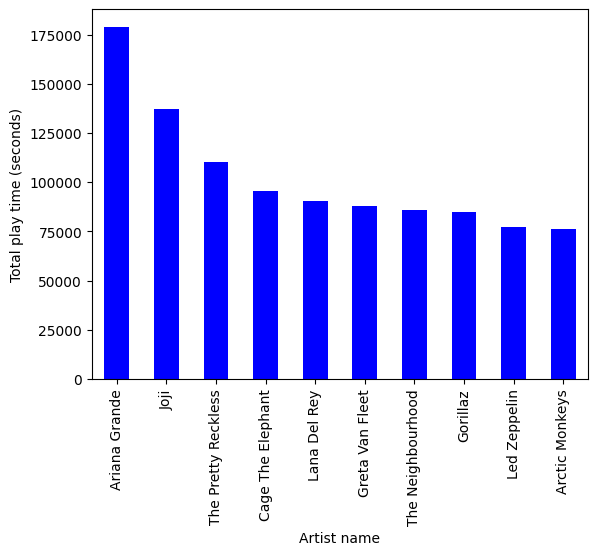

In [16]:
artists_df = df.groupby('artistName')['secPlayed'].sum()

top_10_artists = artists_df.nlargest(10)

top_10_artists.plot(kind="bar",color="b")
plt.xlabel("Artist name")
plt.ylabel("Total play time (seconds)")

#### 2.6 Finding top 10 favorite songs
Find the top `ten` songs with the highest play time. Create a graph visualizing the results.

Text(0, 0.5, 'Total play time (seconds)')

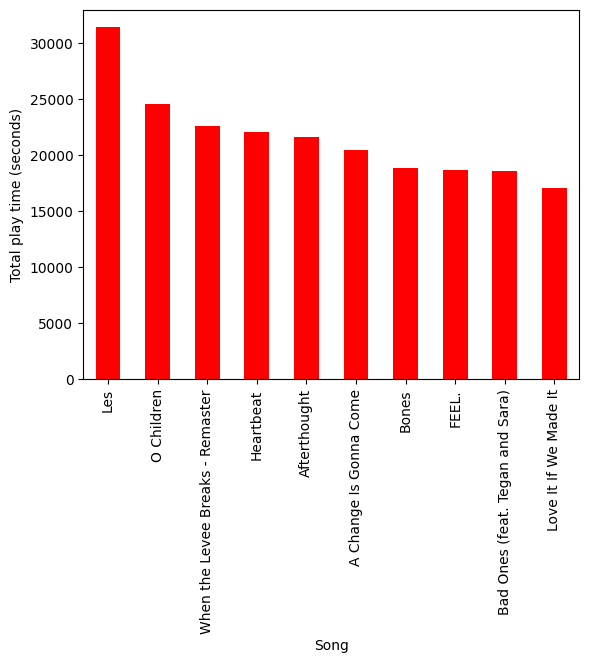

In [17]:
songs_df = df.groupby("trackName")["secPlayed"].sum()

top_10_songs = songs_df.nlargest(10)

top_10_songs.plot(kind="bar",color="r")
plt.xlabel("Song")
plt.ylabel("Total play time (seconds)")

## Part 3: Further analysis

#### 3.0 Average listening time by hour
Generate a plot that displays the average amount of time that music is played for each hour of the day.

Text(0, 0.5, 'Average track play time (seconds)')

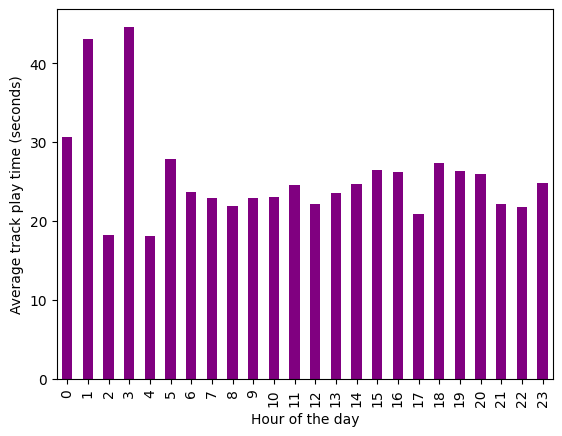

In [18]:
listening_Time_By_Hour = df.groupby(df["dateTime"].dt.hour)["secPlayed"].mean()

listening_Time_By_Hour.plot(kind="bar",color="purple")
plt.xlabel("Hour of the day")
plt.ylabel("Average track play time (seconds)")


#### 3.1 Morning music and evening music
I think many people find that some types of music are more suitable for morning listening and some music is more suitable for evening listening. Create a plot that compares the play time of the artists *Leonard Cohen* and *Rage Against the Machine* on an hour-by-hour basis. See if there are any differences.

Text(0, 0.5, 'Mean play time in 2023 (seconds)')

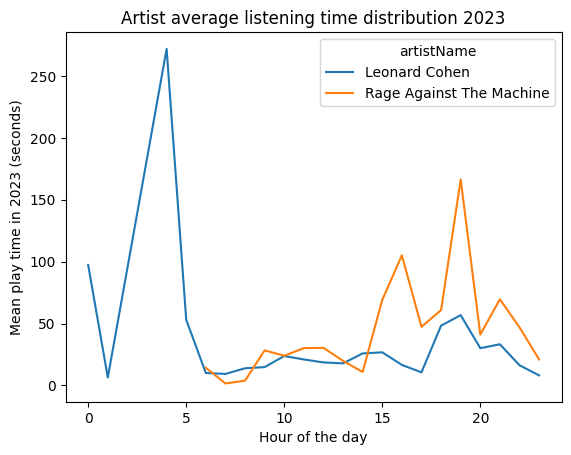

In [19]:
artists = df[df["artistName"].isin(["Leonard Cohen", "Rage Against The Machine"]) ]

# Mean
artist_comparison_mean = artists.groupby([artists["dateTime"].dt.hour, artists["artistName"]])["secPlayed"].mean().unstack()

artist_comparison_mean.plot(kind="line")
plt.title("Artist average listening time distribution 2023")
plt.xlabel("Hour of the day")
plt.ylabel("Mean play time in 2023 (seconds)")


#### 3.2 Analysing skipped songs
Determining whether a song was skipped or listened to can be challenging. For this analysis, we'll simplify by defining a skipped song as any track played for less than 30 seconds. Conversely, a song played for 30 seconds or more is considered listened to. \
 Add a column to your DataFrame to reflect this criteria: set the value to 1 if the song was played for less than 30 seconds (indicating a skipped song), and 0 if it was played for 30 seconds or longer.

In [20]:
df["skipped"] = (df["secPlayed"] < 30).astype(int)
print(df)

                endTime      artistName                        trackName  \
10881  2023-01-01 01:17   Ariana Grande                          7 rings   
10882  2023-01-01 01:17   Ariana Grande                          7 rings   
10883  2023-01-01 01:17   Ariana Grande                        positions   
10884  2023-01-01 01:17       Peach Pit                  Being so Normal   
10885  2023-01-01 01:17  Kelly Clarkson         Santa, Can’t You Hear Me   
...                 ...             ...                              ...   
11962  2023-12-07 21:13  Arctic Monkeys                   Snap Out Of It   
11968  2023-12-07 21:13   Ariana Grande  off the table (with The Weeknd)   
11970  2023-12-07 21:14   Leonard Cohen             Thanks for the Dance   
11969  2023-12-07 21:14   Ariana Grande                          my hair   
11971  2023-12-07 21:17    The Vaccines   Your Love Is My Favourite Band   

                 dateTime  secPlayed  skipped  
10881 2023-01-01 01:17:00      0.139   

#### 3.3 Plotting skipped songs
Create a pie-chart that compares amount of skipped songs to amount of non-skipped songs.

Text(0, 0.5, '')

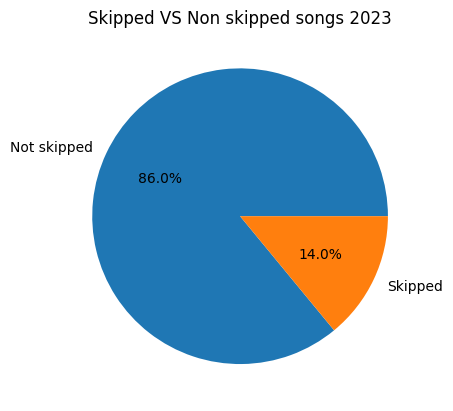

In [21]:
skipped = df["skipped"].value_counts()

skipped.plot(kind="pie", labels=["Not skipped", "Skipped"], autopct="%1.1f%%")
plt.title("Skipped VS Non skipped songs 2023")
plt.ylabel("")

#### 3.4 Artists by percentage of songs skipped
For each artist in the dataset, calculate which percentage of their songs was skipped. Store this information in a new DataFrame called `df_skipped`. Store the percentage of skipped songs in a new column named `SkipRate`\
\
**Example**: If an artist has **100** songs in your dataset and **25** of these were skipped, the percentage of skipped songs for this artist would be $\frac{25}{100}=25\%$

In [22]:
df_skipped = pd.DataFrame(df.groupby("artistName")["skipped"].mean())
df_skipped["skipRate"] = df_skipped["skipped"] * 100
print(df_skipped)

                skipped    skipRate
artistName                         
10cc           0.678571   67.857143
2Pac           0.861598   86.159844
3 Doors Down   0.500000   50.000000
4 Non Blondes  0.721311   72.131148
50 Cent        0.678571   67.857143
...                 ...         ...
squeeda        0.666667   66.666667
tenkousei.     1.000000  100.000000
trxxshed       0.500000   50.000000
xander.        0.375000   37.500000
Édith Piaf     0.941935   94.193548

[956 rows x 2 columns]


#### 3.5 Comparing artists by skip-rate 
Find the `three` top artists with the lowest skip-rate and the `three` with the highest. Print their names, along with their skip-rate.

In [23]:
# lowest
least_skipped_artists = df_skipped["skipRate"].nsmallest(3)
print(least_skipped_artists, "\n")

# highest
most_skipped_artists = df_skipped["skipRate"].nlargest(3)
print(most_skipped_artists)

artistName
Gloria Gaynor     0.000000
Roc Boyz         11.111111
LACES            14.285714
Name: skipRate, dtype: float64 

artistName
A Problem Squared    100.0
Acid Ghost           100.0
Albert Hammond Jr    100.0
Name: skipRate, dtype: float64


## Part 4: God Is a Data Scientist - The Ariana Deep-Dive

#### 4.0 Ariana-DataFrame: 
Create a new DataFrame called *df_ariana*, containing only rows with music by Ariana Grande.

In [24]:
df_ariana = df[df["artistName"] == "Ariana Grande"]

print(df_ariana)

                endTime     artistName                        trackName  \
10881  2023-01-01 01:17  Ariana Grande                          7 rings   
10882  2023-01-01 01:17  Ariana Grande                          7 rings   
10883  2023-01-01 01:17  Ariana Grande                        positions   
10887  2023-01-01 01:17  Ariana Grande                       Santa Baby   
10888  2023-01-01 01:17  Ariana Grande     Right There (feat. Big Sean)   
...                 ...            ...                              ...   
11948  2023-12-07 17:46  Ariana Grande           Almost Is Never Enough   
11955  2023-12-07 20:51  Ariana Grande                            needy   
11961  2023-12-07 21:13  Ariana Grande                    pete davidson   
11968  2023-12-07 21:13  Ariana Grande  off the table (with The Weeknd)   
11969  2023-12-07 21:14  Ariana Grande                          my hair   

                 dateTime  secPlayed  skipped  
10881 2023-01-01 01:17:00      0.139        1  
108

#### 4.1 Average skip rate
Create a histogram of the distribution of the skip-rate values of the different artists in your DataFrame  `df_skipped`, with skip rates on one axis and number of artists on the other. \
\
Then, retrieve the skip rate for Ariana Grande from your DataFrame `df_skipped`. Run the code in the cell below. Where on this distribution does Ariana Grande fall? Do I skip her songs more than average, or less?

Text(0, 0.5, 'Number of Artists')

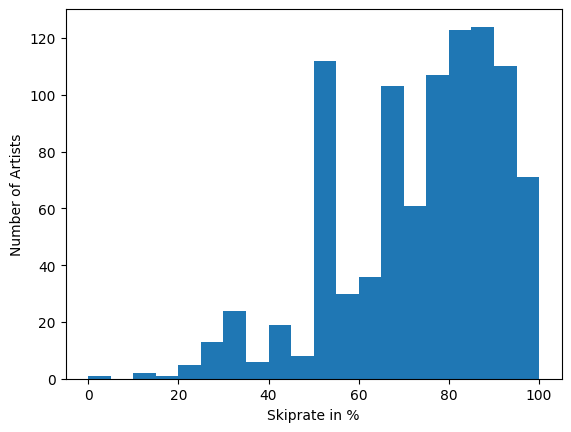

In [25]:
df_skipped["skipRate"].plot(kind="hist", bins=20)

plt.xlabel("Skiprate in %")
plt.ylabel("Number of Artists")

In [26]:
print("skiprate:", df_skipped.loc["Ariana Grande", "skipRate"], "\n")

print("Mean skiprate", df_skipped["skipRate"].mean(), "\n")

# Looking at the mean skiprate of all the artists combined, Ariana is skipped more then avarage. 

print(top_10_artists)


skiprate: 99.52939959662822 

Mean skiprate 73.04822293282288 

artistName
Ariana Grande          178996.003
Joji                   137229.562
The Pretty Reckless    110293.430
Cage The Elephant       95587.575
Lana Del Rey            90543.113
Greta Van Fleet         88026.405
The Neighbourhood       85673.375
Gorillaz                84858.371
Led Zeppelin            77030.802
Arctic Monkeys          76444.236
Name: secPlayed, dtype: float64


### Part 4: Questions
Q1: Did I skip a lot of Ariana Grande's songs, or did I not, compared to the rest of the dataset?

According to dataframe analysis you skipped roughly 99.5% (practically all) of Ariana Grande songs.

Q2: What might be some possible reasons for Ariana Grande to be my nr.1 artist?

According to our conditions we mark a song as skipped when it is listened to for less than 30 seconds. 
When we look at the top 10 artist by playtime we can see that Ariana Grande takes first place, with a total play time of 49 hours and 26 minutes (178006  seconds). 

The owner of the spotify account is under high suspicion of having a guilty pleasure song / songs from Ariana Grande's library. They might constantly listen to only certain parts of her songs, or maybe they sang the chorus on repeat during a 49 hour long road trip.